**Upload and Preprocess Dataset**

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings

warnings.filterwarnings("ignore")

# Define URLs for each client's dataset
client_1_url = "https://raw.githubusercontent.com/Me-Rajdip/Data-Set/refs/heads/main/VFL%20Dataset/Modified_Cardiovascular_Disease_Dataset.csv"
client_2_url = "https://raw.githubusercontent.com/Me-Rajdip/Data-Set/refs/heads/main/VFL%20Dataset/heart.csv"
client_3_url = "https://raw.githubusercontent.com/Me-Rajdip/Data-Set/refs/heads/main/VFL%20Dataset/Cardiovascular_Disease_Dataset.csv"

# Load the datasets
client_1_df = pd.read_csv(client_1_url)
client_2_df = pd.read_csv(client_2_url)
client_3_df = pd.read_csv(client_3_url)

# Drop "Unnamed" column from client_1_df
client_1_df = client_1_df.loc[:, ~client_1_df.columns.str.contains('^Unnamed')]

# Drop "patientid" column from client_3_df
client_3_df = client_3_df.drop(columns=["patientid"], errors='ignore')

# Target variable for each client
client_1_target = 'target'
client_2_target = 'HeartDisease'
client_3_target = 'target'

# Separate numeric and categorical columns for Client 2
client_2_numeric_cols = client_2_df.select_dtypes(include=[np.number]).columns.tolist()
client_2_categorical_cols = client_2_df.select_dtypes(exclude=[np.number]).columns.tolist()

# Fill missing values for numeric columns with median
client_1_df = client_1_df.fillna(client_1_df.median())
client_2_df[client_2_numeric_cols] = client_2_df[client_2_numeric_cols].fillna(client_2_df[client_2_numeric_cols].median())
client_3_df = client_3_df.fillna(client_3_df.median())

# Apply one-hot encoding for categorical columns in Client 2
encoder = OneHotEncoder(drop='first', sparse_output=False)
client_2_encoded = pd.DataFrame(encoder.fit_transform(client_2_df[client_2_categorical_cols]))
client_2_encoded.columns = encoder.get_feature_names_out(client_2_categorical_cols)
# Drop original categorical columns and concatenate the encoded ones
client_2_df = pd.concat([client_2_df[client_2_numeric_cols], client_2_encoded], axis=1)

# Split the data into train and test sets
client_1_train, client_1_test = train_test_split(client_1_df, test_size=0.2, random_state=42)
client_2_train, client_2_test = train_test_split(client_2_df, test_size=0.2, random_state=42)
client_3_train, client_3_test = train_test_split(client_3_df, test_size=0.2, random_state=42)

# Prepare datasets for training (no alignment needed, just use the existing features)
def prepare_dataset(df, features, target):
    scaler = StandardScaler()
    X = scaler.fit_transform(df[features])
    y = df[target].values
    return {"features": X, "labels": y}

client_1_data = prepare_dataset(client_1_train, client_1_df.columns.difference([client_1_target]), client_1_target)
client_2_data = prepare_dataset(client_2_train, client_2_df.columns.difference([client_2_target]), client_2_target)
client_3_data = prepare_dataset(client_3_train, client_3_df.columns.difference([client_3_target]), client_3_target)


**Normal VFL**

Early stopping at round 4

Final Global Model Accuracy: 0.8656
Final Global Model Precision: 0.8291
Final Global Model Recall: 0.9571
Final Global Model F1 Score: 0.8885
|   Round | Client        | Stage           | Weights                                                                                                                                                                                                                                                                                                                                                                  |     Bias |   Accuracy |   Precision |   Recall |   F1 Score |
|--------:|:--------------|:----------------|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

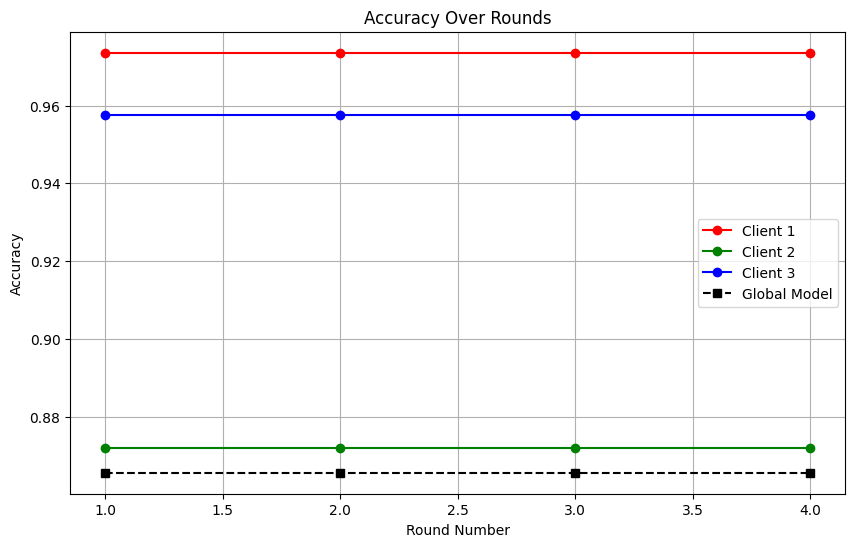

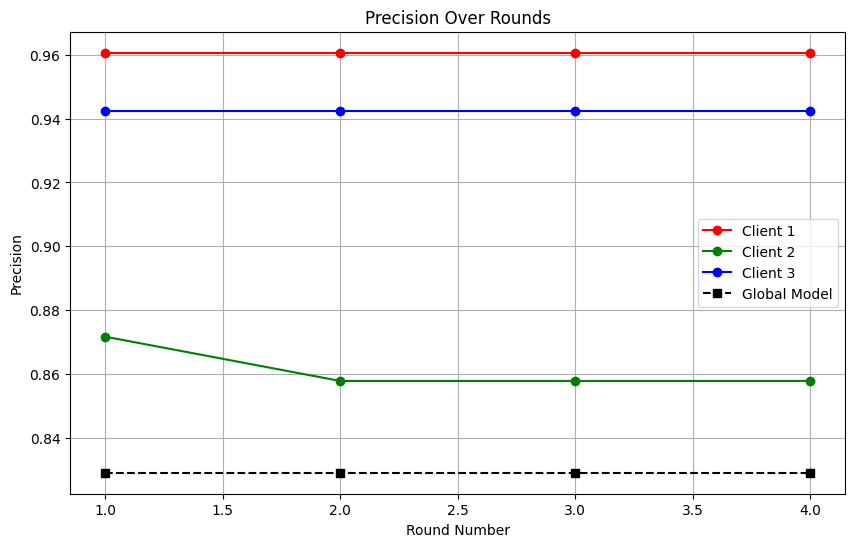

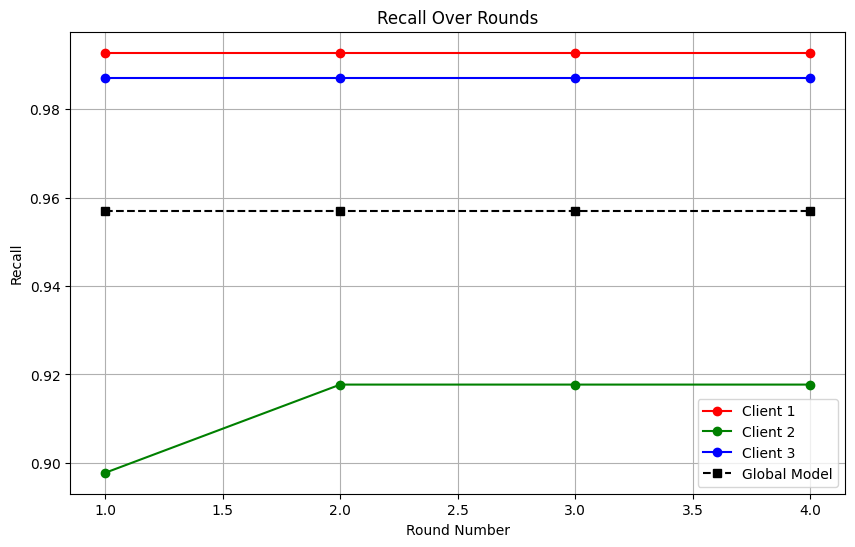

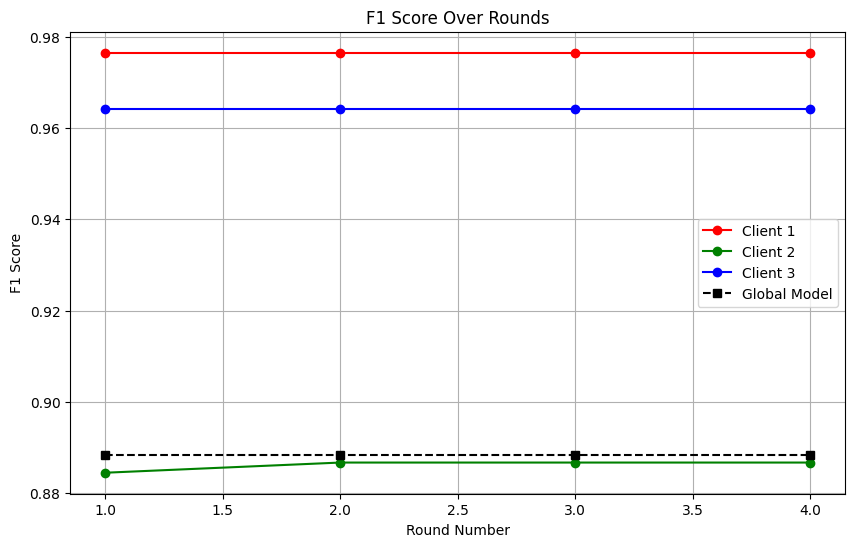

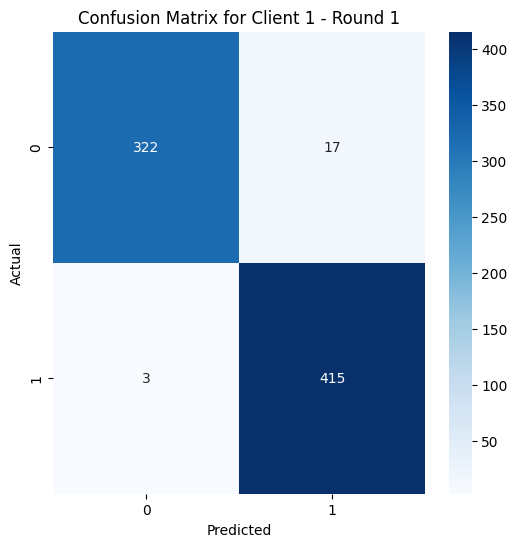

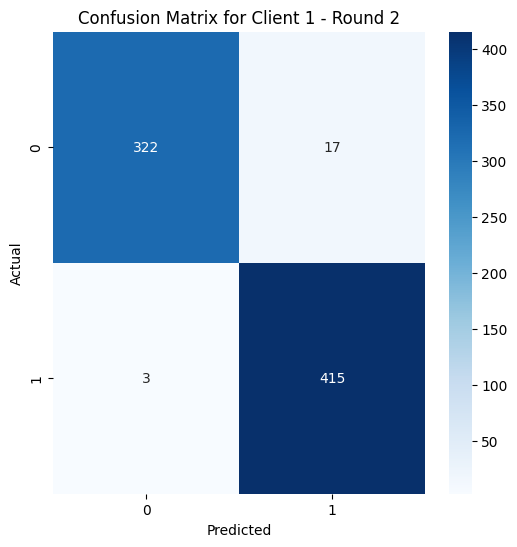

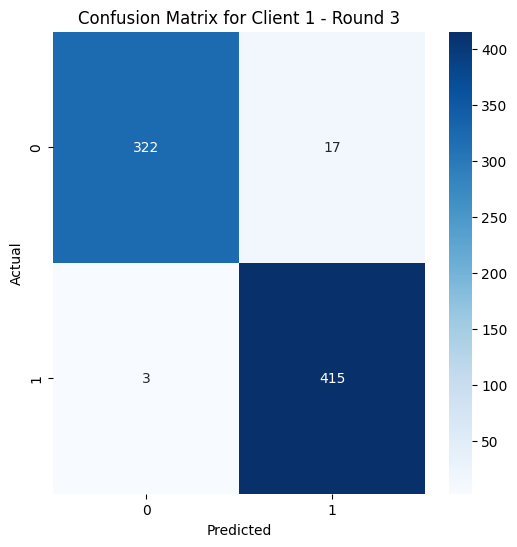

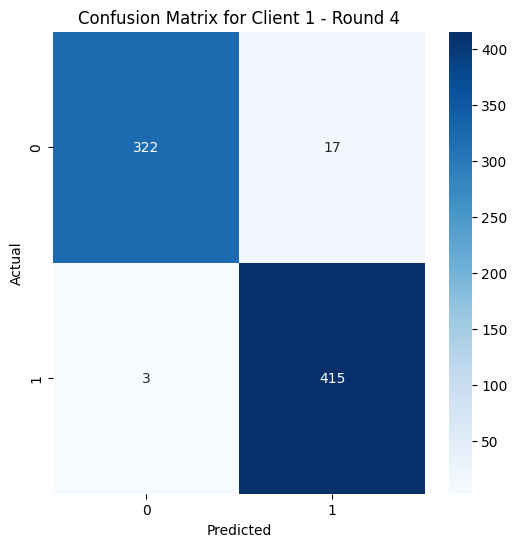

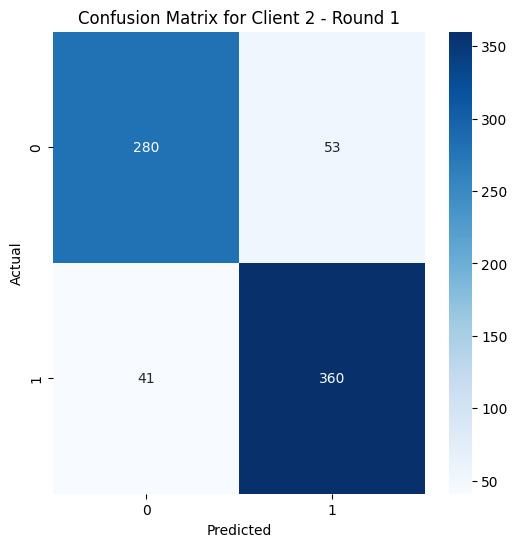

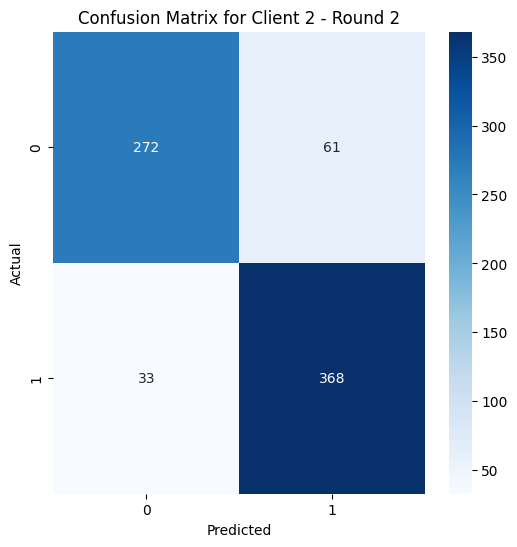

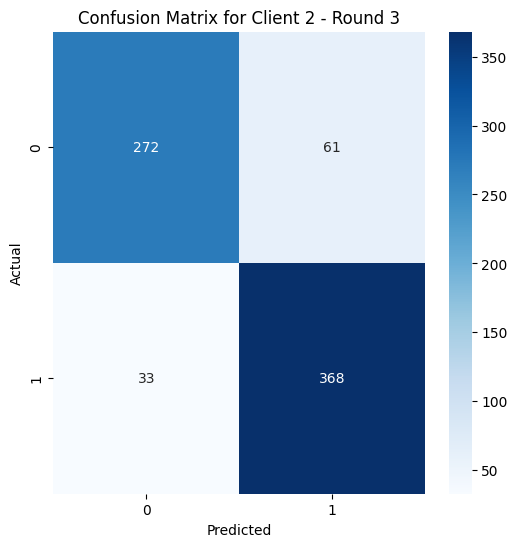

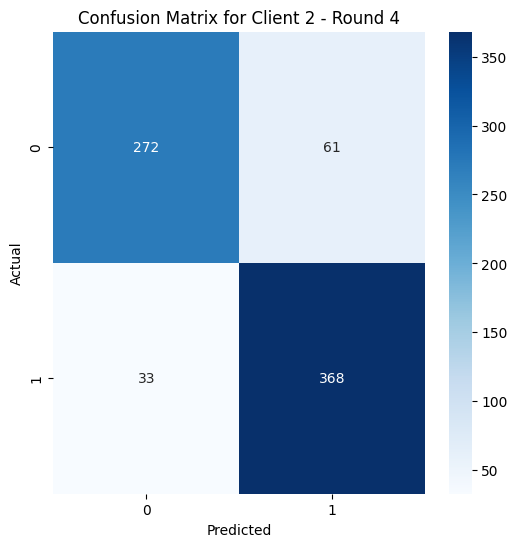

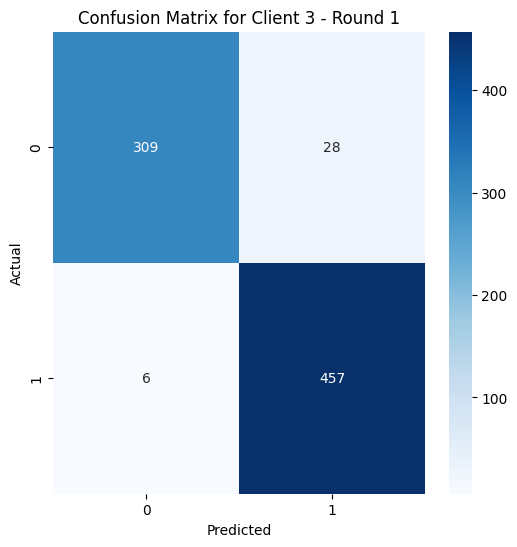

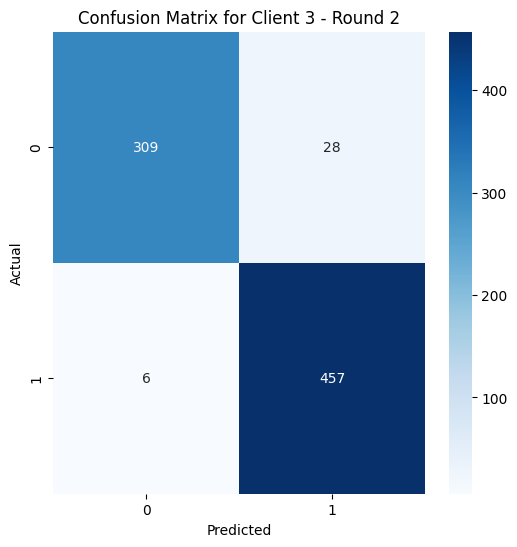

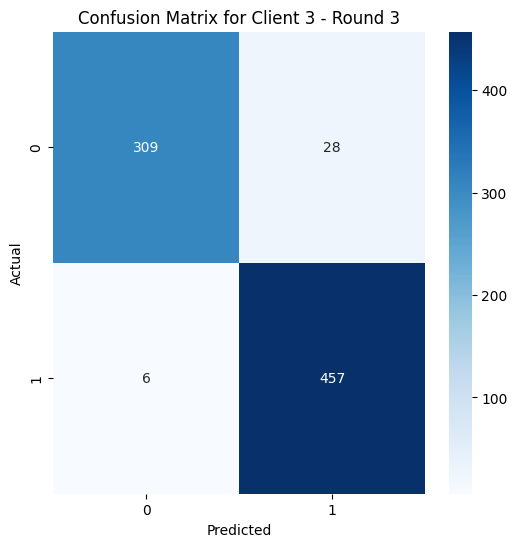

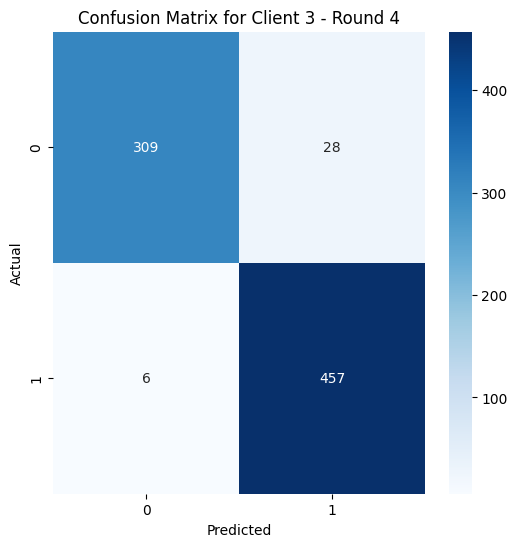

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from docx import Document
import os

def logistic_regression_local_update(dataset, weights, bias, learning_rate=0.1, num_iterations=100):
    model = LogisticRegression(max_iter=num_iterations, solver='liblinear')
    model.fit(dataset["features"], dataset["labels"])
    weights = model.coef_.flatten()
    bias = model.intercept_[0]
    return weights, bias

def clip_update(update, threshold):
    norm = np.linalg.norm(update)
    if norm > threshold:
        return update * (threshold / norm)
    else:
        return update

def evaluate_model(dataset, weights, bias):
    X = dataset["features"]
    y = dataset["labels"]
    linear_model = np.dot(X, weights) + bias
    y_pred = (1 / (1 + np.exp(-linear_model))) >= 0.5
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    cm = confusion_matrix(y, y_pred)
    return acc, prec, rec, f1, cm

def federated_learning_withoutdp(
    datasets, initial_weights, initial_biases, learning_rate, clipping_threshold, num_rounds
):
    weights = [w.copy() for w in initial_weights]
    biases = [b for b in initial_biases]
    results = []
    best_global_acc = 0.0
    patience = 3
    no_improvement = 0
    
    # For storing metrics for plotting
    accuracy_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    precision_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    recall_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    f1_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    confusion_matrices = {f"Client {i+1}": [] for i in range(len(datasets))}
    
    global_accuracy = []
    global_precision = []
    global_recall = []
    global_f1 = []

    for round_num in range(1, num_rounds + 1):
        local_weight_updates = []
        local_bias_updates = []
        local_clipped_updates = []
        target_accuracies = []

        # Client updates
        for i, dataset in enumerate(datasets):
            if round_num == 1:
                # Initial training on dataset
                weight_update, bias_update = logistic_regression_local_update(
                    dataset, weights[i], biases[i], learning_rate
                )
            else:
                # Subsequent rounds: Use previous adjusted weights/biases directly
                weight_update = weights[i].copy()
                bias_update = biases[i]

            # Clip updates
            clipped_weight = clip_update(weight_update, clipping_threshold)
            clipped_bias = clip_update(np.array([bias_update]), clipping_threshold)[0]

            # Evaluate and store metrics
            acc, prec, rec, f1, cm = evaluate_model(dataset, clipped_weight, clipped_bias)
            target_accuracies.append(acc)
            local_clipped_updates.append((clipped_weight, clipped_bias))
            
            # Store metrics for plotting
            accuracy_history[f"Client {i+1}"].append(acc)
            precision_history[f"Client {i+1}"].append(prec)
            recall_history[f"Client {i+1}"].append(rec)
            f1_history[f"Client {i+1}"].append(f1)
            confusion_matrices[f"Client {i+1}"].append(cm)

            local_weight_updates.append(clipped_weight)
            local_bias_updates.append(clipped_bias)

            # Log results
            results.append({
                "Round": round_num, "Client": i+1, "Stage": "Update",
                "Weights": clipped_weight.tolist(), "Bias": clipped_bias,
                "Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1
            })

        # Aggregate updates
        aggregated_weight = np.mean(local_weight_updates, axis=0)
        aggregated_bias = np.mean(local_bias_updates)

        # Log aggregated model
        combined_data = {
            "features": np.vstack([d["features"] for d in datasets]),
            "labels": np.hstack([d["labels"] for d in datasets])
        }
        acc_noisy, prec_noisy, rec_noisy, f1_noisy, _ = evaluate_model(combined_data, aggregated_weight, aggregated_bias)
        results.append({
            "Round": round_num, "Client": "Global Server", "Stage": "Aggregated",
            "Weights": aggregated_weight.tolist(), "Bias": aggregated_bias,
            "Accuracy": acc_noisy, "Precision": prec_noisy,
            "Recall": rec_noisy, "F1 Score": f1_noisy
        })

        # Client adjustment phase
        for i in range(len(datasets)):
            dataset = datasets[i]
            target_acc = target_accuracies[i]
            clipped_weight, clipped_bias = local_clipped_updates[i]

            # Compute delta: Difference between client's original clipped model and global
            delta_weight = clipped_weight - aggregated_weight
            delta_bias = clipped_bias - aggregated_bias

            # Line search for alpha to reach target accuracy
            best_alpha = 0.0
            best_acc = 0.0
            for alpha in np.linspace(0, 1, 11):
                w_test = aggregated_weight + alpha * delta_weight
                b_test = aggregated_bias + alpha * delta_bias
                acc, _, _, _, _ = evaluate_model(dataset, w_test, b_test)

                if acc >= target_acc:
                    best_alpha = alpha
                    best_acc = acc
                    break
                if acc > best_acc:
                    best_alpha = alpha
                    best_acc = acc

            # Update client model
            new_weight = aggregated_weight + best_alpha * delta_weight 
            new_bias = aggregated_bias + best_alpha * delta_bias 

            # Log adjusted model
            acc_adj, prec_adj, rec_adj, f1_adj, _ = evaluate_model(dataset, new_weight, new_bias)
            results.append({
                "Round": round_num, "Client": i+1, "Stage": "Adjusted",
                "Weights": new_weight.tolist(), "Bias": new_bias,
                "Accuracy": acc_adj, "Precision": prec_adj, "Recall": rec_adj, "F1 Score": f1_adj
            })

            # Update client weights and biases
            weights[i] = new_weight
            biases[i] = new_bias

        # Evaluate global model (average of client models)
        global_weights = np.mean(weights, axis=0)
        global_bias = np.mean(biases)
        acc_global, prec_global, rec_global, f1_global, _ = evaluate_model(combined_data, global_weights, global_bias)
        results.append({
            "Round": round_num, "Client": "Global Model", "Stage": "Post Adjustment",
            "Weights": global_weights.tolist(), "Bias": global_bias,
            "Accuracy": acc_global, "Precision": prec_global, "Recall": rec_global, "F1 Score": f1_global
        })
        
        # Store global metrics
        global_accuracy.append(acc_global)
        global_precision.append(prec_global)
        global_recall.append(rec_global)
        global_f1.append(f1_global)

        # Early stopping
        if acc_global > best_global_acc + 0.0001:
            best_global_acc = acc_global
            no_improvement = 0
        else:
            no_improvement += 1
        if no_improvement >= patience:
            print(f"Early stopping at round {round_num}")
            break

    # Final evaluation
    final_weights = np.mean(weights, axis=0)
    final_bias = np.mean(biases)
    acc_final, prec_final, rec_final, f1_final, _ = evaluate_model(combined_data, final_weights, final_bias)
    print(f"\nFinal Global Model Accuracy: {acc_final:.4f}")
    print(f"Final Global Model Precision: {prec_final:.4f}")
    print(f"Final Global Model Recall: {rec_final:.4f}")
    print(f"Final Global Model F1 Score: {f1_final:.4f}")
    
    results_df = pd.DataFrame(results)
    print(results_df.to_markdown(index=False))
    
    # Save results and plots
    save_results_and_plots(results_df, accuracy_history, precision_history, recall_history, 
                         f1_history, confusion_matrices, global_accuracy, global_precision,
                         global_recall, global_f1, len(datasets), round_num)

    return results_df, accuracy_history, precision_history, recall_history, f1_history, confusion_matrices

def save_results_and_plots(results_df, accuracy, precision, recall, f1_score, 
                         confusion_matrices, global_acc, global_prec, 
                         global_rec, global_f1, num_clients, num_rounds):
    # Create directory
    if not os.path.exists("VFL_Without_DP"):
        os.makedirs("VFL_Without_DP")

    # Save results as Word file
    doc = Document()
    doc.add_heading('Federated Learning Results (Without DP)', 0)
    table = doc.add_table(rows=1, cols=len(results_df.columns))
    table.style = 'Table Grid'
    hdr_cells = table.rows[0].cells
    for i, col in enumerate(results_df.columns):
        hdr_cells[i].text = col
    for _, row in results_df.iterrows():
        row_cells = table.add_row().cells
        for i, value in enumerate(row):
            row_cells[i].text = str(value)
    doc.save("VFL_Without_DP/results.docx")

    # Plot metrics
    rounds = list(range(1, num_rounds + 1))
    colors = ['red', 'green', 'blue', 'orange', 'purple'][:num_clients]

    def plot_metric(metric_data, global_metric, title, ylabel, filename):
        plt.figure(figsize=(10, 6))
        for i, (client, values) in enumerate(metric_data.items()):
            plt.plot(rounds, values[:num_rounds], marker='o', color=colors[i], label=client)
        plt.plot(rounds, global_metric[:num_rounds], marker='s', color='black', linestyle='--', label='Global Model')
        plt.xlabel("Round Number")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(True)
        plt.savefig(f"VFL_Without_DP/{filename}.png")
        plt.show()

    plot_metric(accuracy, global_acc, "Accuracy Over Rounds", "Accuracy", "accuracy")
    plot_metric(precision, global_prec, "Precision Over Rounds", "Precision", "precision")
    plot_metric(recall, global_rec, "Recall Over Rounds", "Recall", "recall")
    plot_metric(f1_score, global_f1, "F1 Score Over Rounds", "F1 Score", "f1_score")

    # Plot confusion matrices
    for client, cms in confusion_matrices.items():
        for round_num, cm in enumerate(cms[:num_rounds], 1):
            plt.figure(figsize=(6, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f"Confusion Matrix for {client} - Round {round_num}")
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.savefig(f"VFL_Without_DP/{client}_Round_{round_num}_confusion_matrix.png")
            plt.show()


datasets = [client_1_data, client_2_data, client_3_data]

# Padding features to ensure uniform length
def pad_features_to_max_size(datasets):
    max_features = max(d["features"].shape[1] for d in datasets)
    for d in datasets:
        pad_width = max_features - d["features"].shape[1]
        if pad_width > 0:
            d["features"] = np.hstack([d["features"], np.zeros((d["features"].shape[0], pad_width))])
    return datasets, max_features



# Pad datasets and initialize weights
datasets, max_features = pad_features_to_max_size(datasets)
initial_weights = [np.zeros(max_features) for _ in datasets]
initial_biases = [0.0 for _ in datasets]

# Run Federated Learning without DP
results_df, accuracy, precision, recall, f1_score, confusion_matrices = federated_learning_withoutdp(
    datasets=datasets,
    initial_weights=initial_weights,
    initial_biases=initial_biases,
    learning_rate=0.1,
    clipping_threshold=3.0,
    num_rounds=10
)